In [104]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.quantum_info import random_unitary
from qiskit_aer import AerSimulator

In [105]:
def fourier_gate(d):
    """
    Generates a Fourier Transform gate for a d-dimensional system.
    F|j> = 1/sqrt(d) * sum_k (omega^(jk) |k>)
    """
    omega = np.exp(2j * np.pi / d)
    F = np.zeros((d, d), dtype=complex)
    for j in range(d):
        for k in range(d):
            F[k, j] = (1 / np.sqrt(d)) * (omega**(j * k))
    return F

def sum_gate(d):
    """
    Generates a SUM gate for a d-dimensional system (qudits).
    SUM|j>|k> = |j>|(j + k) mod d> 
    """
    dim = d**2
    SUM = np.zeros((dim, dim), dtype=complex)
    for j in range(d):
        for k in range(d):
            inp = j + k * d
            out = j + d*((j+k) % d)
            SUM[out, inp] = 1
    return SUM

def x_gate(d):
    """
    Generates a genaralized X gate.
    X = sum_j |j><(j+1)%d|
    """
    X = np.zeros((d, d), dtype=complex)
    for j in range(d):
        X[j, (j + 1) % d] = 1
    return X

def z_gate(d):
    """
    Generates a generalized Z gate.
    Z = sum_j omega^j |j><j|
    """
    omega = np.exp(2j * np.pi / d)
    Z = np.zeros((d, d), dtype=complex)
    for j in range(d):
        Z[j, j] = omega**j
    return Z

In [106]:
def create_teleportation_circuit(d):
    """
    Creates a quantum circuit for teleporting a d-dimensional state (qudit).
    """
    if (d & (d - 1)) != 0:
        raise ValueError("Dimension d must be a power of 2 for qubit mapping.")
    # Initialize Gates for dimension d
    F = fourier_gate(d)
    SUM = sum_gate(d)
    X = x_gate(d)
    Z = z_gate(d)
    # Random state preparation by unitary operator
    U_prep = random_unitary(d, seed=1337)

    # Define registers and circuit
    # We map each qudit to log2(d) qubits, so we need log2(d) qubits for psi, A, and B each
    bits = int(np.log2(d))
    psi = QuantumRegister(bits, "psi")
    A = QuantumRegister(bits, "A")
    B = QuantumRegister(bits, "B")
    cr_m = ClassicalRegister(bits, "m")
    cr_n = ClassicalRegister(bits, "n")
    cr_z = ClassicalRegister(bits, "z")
    qc = QuantumCircuit(psi, A, B, cr_m, cr_n, cr_z)

    # Prepare completely UNKNOWN/RANDOM state psi
    qc.unitary(U_prep, psi, label="U_prep")
    qc.barrier()

    # We entangle Alice's and Bob's qudits mapped to log2​(d) qubits using the SUM and F gate
    qc.unitary(F, A, label=f"F{d}")
    qc.unitary(SUM, [*A,*B], label=f"SUM{d}")
    qc.barrier()

    # Now we apply the inverse of SUM and F gates to Alice's qudits mapped to log2​(d) qubits
    qc.unitary(SUM.T, [*psi,*A], label=f"SUM{d}†")
    qc.unitary(np.conjugate(F.T), psi, label=f"F{d}†")
    qc.barrier()

    # Now Alice measures her qudits mapped to log2​(d) qubits
    qc.measure(psi, cr_m)
    qc.measure(A, cr_n)
    qc.barrier()

    # We apply the necessary gates to Bob's unknown state based on Alice's measurement results
    # Create all possible powers of X and Z for corrections
    X_powers = [np.linalg.matrix_power(X,i) for i in range(d)]
    Z_powers = [np.linalg.matrix_power(Z,i) for i in range(d)]
    # Apply Z^m correction based on m register
    for m in range(1,d):
        with qc.if_test((cr_m, m)):
            qc.unitary(Z_powers[m], B, label=f"Z^{m}")
    # Apply X^n correction based on n register
    for n in range(1,d):
        with qc.if_test((cr_n, n)):
            qc.unitary(X_powers[n], B, label=f"X^{n}")

    # Finally, we apply the inverse of u to Bob's qudit mapped to log2​(d) qubits and measure for verification of the teleportation
    qc.unitary(U_prep.adjoint(), B, label="U_prep†")
    qc.barrier()

    qc.measure(B, cr_z)
    return qc

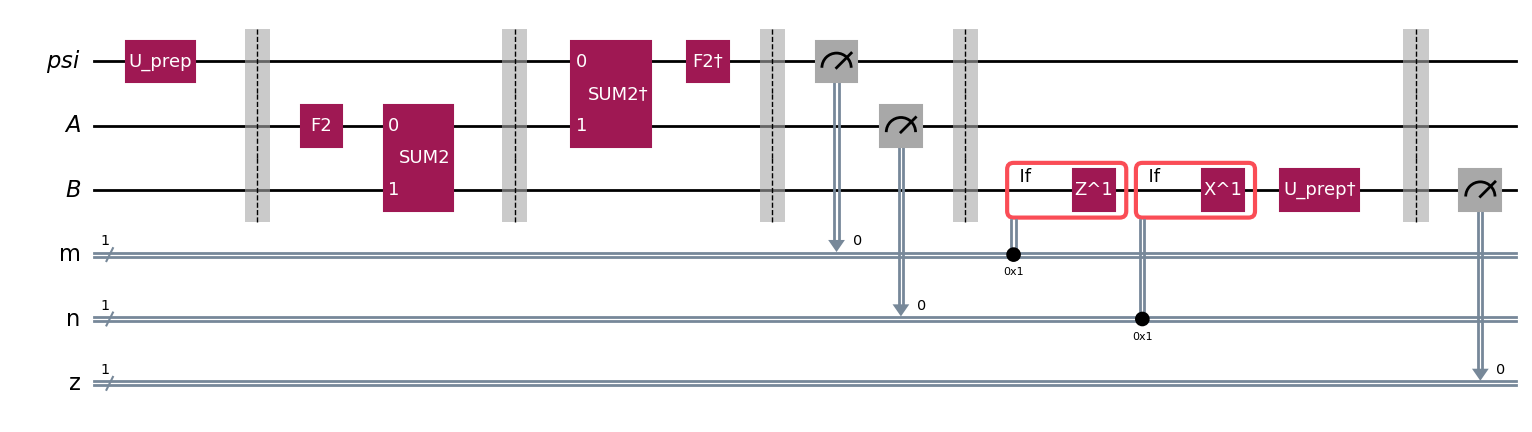

In [107]:
# Creating and visualizing the teleportation circuit for d=4 (2 qubits per qudit)
d = 2
qc = create_teleportation_circuit(d)
qc.draw("mpl")

In [108]:
# Initialize the AerSimulator and run on simulator
sampler = Sampler(mode=AerSimulator())
job = sampler.run([qc])
res = job.result()

In [109]:
# Initialize runtime service and backend
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
# Optimize circuit for backend
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
# Run circuit using Sampler
sampler = Sampler(mode=backend)
job = sampler.run([qc_isa])
res = job.result()

Succes rate: 95.26%


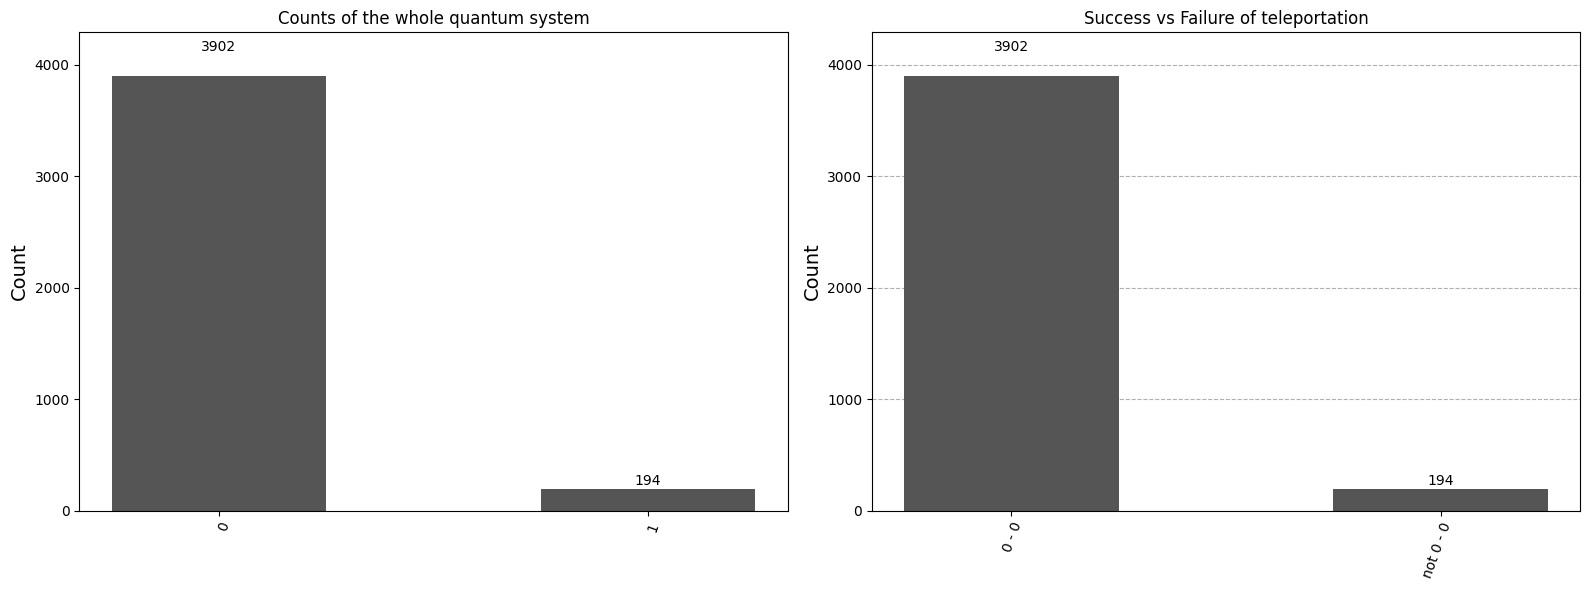

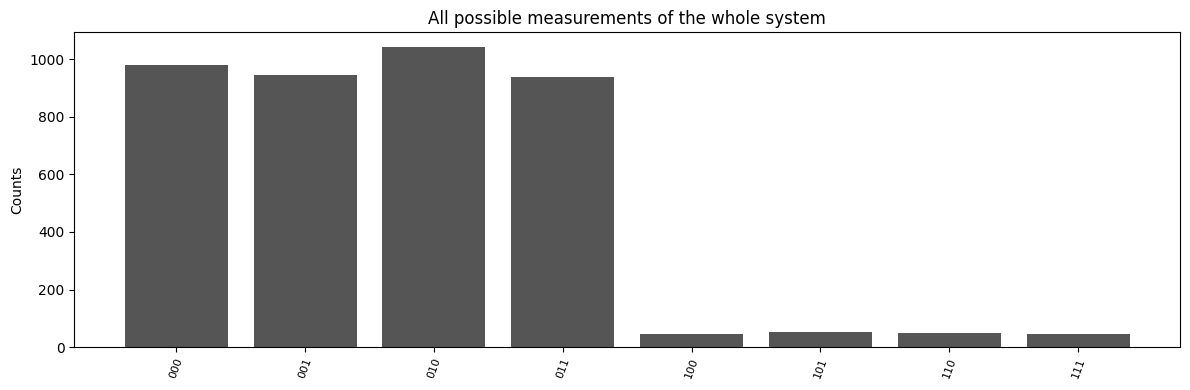

In [110]:
# Retrieve bitstrings for all registers from the result
z_bits = res[0].data.z.get_bitstrings()
n_bits = res[0].data.n.get_bitstrings()
m_bits = res[0].data.m.get_bitstrings()

# 1. Bob's Final State
bob_data = {str(i): 0 for i in range(d)}
# Initialize all possible states (z n m) with 0 - Teleported (z) first
all_states_data = {f"{z}{n}{m}": 0 for z in range(d) for n in range(d) for m in range(d)}

for z, n, m in zip(z_bits, n_bits, m_bits):
    # Bob's data
    bob_val = int(z, 2)
    bob_data[str(bob_val)] += 1

    m_val = int(m, 2)
    n_val = int(n, 2)
    z_val = int(z, 2)

    key = f"{z_val}{n_val}{m_val}"
    if key in all_states_data:
        all_states_data[key] += 1

# 2. Success vs Failure
# Failure is when Bob's state is not 0
success_count = bob_data.get('0', 0)
total_shots = len(z_bits)
failure_count = total_shots - success_count
zero_str = " - " + "0" * int(np.log2(d))
sf_data = { f"0{zero_str}": success_count, f"not 0{zero_str}": failure_count}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Graph 1: Bob's Final State
plot_histogram(bob_data, ax=ax1, color='#555555')
ax1.set_title("Counts of the whole quantum system") 

# Graph 2: Success vs Failure
plot_histogram(sf_data, ax=ax2, color='#555555')
ax2.set_title("Success vs Failure of teleportation")

print("Succes rate: {:.2f}%".format(100 * success_count / total_shots))
plt.tight_layout()
plt.show()

# Graph 3: All options of states ordered by state
sorted_items = sorted(all_states_data.items(), key=lambda item: item[0])
keys = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]

fig_width = max(12, len(keys) * 0.2) 
plt.figure(figsize=(fig_width, 4))
plt.bar(keys, values, color='#555555')
plt.title("All possible measurements of the whole system")
plt.xticks(rotation=70, fontsize=8)
plt.ylabel("Counts")
plt.tight_layout()
plt.show()